# Özel (Custom) Transformer

In [1]:
import pandas as pd
import seaborn as sns

👉 Bu veri setini kullanacağız:

In [2]:
data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/custom_transformer_data.csv")
data.head()

,customer_state,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm,days_until_delivery
0,RJ,SP,1825,53,10,40,9
1,RJ,SP,700,65,18,28,9
2,RJ,SP,1825,53,10,40,11
3,RJ,SP,1825,53,10,40,12
4,RJ,SP,1825,53,10,40,14


- Veri setindeki her bir gözlem, bir ürünün bir `seller_state`’ten bir `customer_state`’e teslim edilmesini temsil eder.  
- Diğer sütunlar, her bir ürünün paketleme özelliklerini açıklar.

🎯 Hedef, sipariş ile teslimat arasındaki gün sayısıdır.

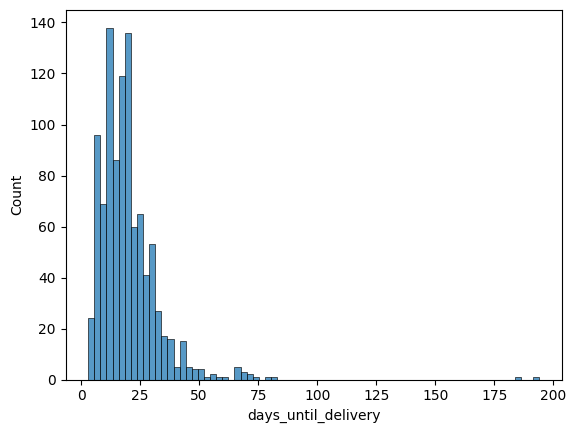

In [3]:
#  Hedefi kontrol et
sns.histplot(data.days_until_delivery);

## 1. Pipeline

👉 `pipe` adlı bir scikit-learn pipeline oluşturun:

- Boyut feature’larından (`dimensions`) bir `volume` feature’ı türetin
- Eğitim için orijinal ürün boyut feature’larını koruyun
- Tüm sayısal feature’ları ölçekleyin
- Kategorik feature’ları encode edin
- Varsayılan ayarlarla bir `Ridge` regresyon estimator’ı ekleyin

**Not:** Bu challenge için holdout yöntemi yok sayılacaktır; yani `train_test_split` kullanmanıza gerek yoktur!

<details><summary><strong>İpuçları</strong></summary>

- Ön işlenmiş feature matrisinizi oluşturmanın birçok yolu vardır (`ColumnTransformer` ve/veya `FeatureUnion` kullanarak). 
    
- Dönüştürülmüş feature matrisiniz garip görünüyorsa, bunun nedeni `OneHotEncoder(sparse_output=True)` varsayılan davranışıyla matrisin "sparse" olarak saklanması olabilir. Bunu tekrar dense bir matrise çevirmek için `.todense()` kullanın.

- Varsayılan NumPy array çıktısı yerine sütun adlarıyla birlikte bir Pandas DataFrame çıktısı almak için, final pipeline’ınızda `.set_output(transform='pandas')` kullanın. (Bunu her bir transformer üzerinde tek tek ayarlamanıza gerek yoktur. Pipeline üzerinde ayarlarsanız, bunu alt aşamalara da aktarır.)

</details>

<br>

<details><summary><strong>Daha fazla ipucu: adım adım yönlendirme</strong> (yalnızca takılırsanız açın)</summary>

Pipeline’ı oluşturmanın en kolay yolu budur.

1. Uzunluk, genişlik ve yükseklik verildiğinde hacmi hesaplayan bir python `function` oluşturun.
2. Aşağıdakilerden oluşan bir hacim hesaplayıcı pipeline oluşturun:
   1. Python `function`’ınızı kullanan bir `FunctionTransformer`.
   1. Ardından bir scaler
3. `ColumnTransformer` kullanarak tam bir preprocessor oluşturun:
   - Orijinal sayısal feature’lar için bir scaler.
   - Kategorik feature’lar için bir encoder.
   - Uzunluk, genişlik ve yükseklik feature’ları için hacim hesaplayıcı pipeline’ınız.
4. Son olarak, tam preprocessor’ınızı ve ardından `Ridge` modelini içeren bir pipeline oluşturun.

</details>

In [4]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge

X = data.drop(columns=['days_until_delivery'])
y = data['days_until_delivery']

def compute_volume(df):
    arr = np.asarray(df)
    volume = (arr[:, 0] * arr[:, 1] * arr[:, 2]).reshape(-1, 1)
    return pd.DataFrame(volume, index=df.index, columns=['volume'])

volume_pipe = Pipeline([
    ('volume_calculator', FunctionTransformer(compute_volume)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num_scaler', StandardScaler(), ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']),
    ('cat_encoder', OneHotEncoder(sparse_output=False, drop='if_binary'), ['customer_state', 'seller_state']),
    ('volume_pipe', volume_pipe, ['product_length_cm', 'product_height_cm', 'product_width_cm'])
]).set_output(transform='pandas')

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
]).set_output(transform='pandas')

In [5]:
pipe.fit(X, y)
print(pipe[:-1].transform(X).columns.tolist())

['num_scaler__product_weight_g', 'num_scaler__product_length_cm', 'num_scaler__product_height_cm', 'num_scaler__product_width_cm', 'cat_encoder__customer_state_AL', 'cat_encoder__customer_state_AM', 'cat_encoder__customer_state_AP', 'cat_encoder__customer_state_BA', 'cat_encoder__customer_state_CE', 'cat_encoder__customer_state_DF', 'cat_encoder__customer_state_ES', 'cat_encoder__customer_state_GO', 'cat_encoder__customer_state_MA', 'cat_encoder__customer_state_MG', 'cat_encoder__customer_state_MS', 'cat_encoder__customer_state_MT', 'cat_encoder__customer_state_PA', 'cat_encoder__customer_state_PB', 'cat_encoder__customer_state_PE', 'cat_encoder__customer_state_PI', 'cat_encoder__customer_state_PR', 'cat_encoder__customer_state_RJ', 'cat_encoder__customer_state_RN', 'cat_encoder__customer_state_RO', 'cat_encoder__customer_state_RS', 'cat_encoder__customer_state_SC', 'cat_encoder__customer_state_SE', 'cat_encoder__customer_state_SP', 'cat_encoder__customer_state_TO', 'cat_encoder__selle

#### 🧪  pipe'ını test et

In [17]:
from nbresult import ChallengeResult

pipe_test = pipe

# Çökmediğini kontrol edin
assert pipe_test.fit(X, y)

result = ChallengeResult(
    'pipe',
    shape = pipe_test[:-1].fit_transform(X).shape
)

result.write()
print(result.check())

/home/kaan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/preprocessing/_function_transformer.py:311: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))
/home/kaan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/preprocessing/_function_transformer.py:311: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))



============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.1.1, pluggy-1.6.0 -- /home/kaan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/kaan/code/sprint_215/S17D1-S-Data-Custom-Transformer/tests
plugins: anyio-4.8.0, typeguard-4.4.2, dash-4.4.1
collecting ... collected 1 item

test_pipe.py::TestPipe::test_pipe_not_crashing PASSED                    [100%]

============================== 1 passed in 0.30s ===============================


💯 You can commit your code:

git add tests/pipe.pickle

git commit -m 'Completed pipe step'

git push origin master



## 2. Train ve Predict

👇 `data`’nın tüm eğitim veri setiniz olduğunu varsayalım.

- Bu veri seti üzerinde pipeline’ınızı `cross_validate` edin (❗️düşük $R^2$ skorları beklenmektedir)
- Şimdi de yeni bir sipariş aldığınızı varsayın: `new_data`  
  Teslimat süresini tahmin edin ve sonucu `prediction` adlı değişkende saklayın

In [6]:
new_data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/custom_transformer_new_order.csv")
new_data

,customer_state,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,RJ,SP,1825,53,10,40


In [7]:
import numpy as np
import pandas as pd

def compute_volume(df):
    arr = np.asarray(df)
    volume = (arr[:, 0] * arr[:, 1] * arr[:, 2]).reshape(-1, 1)
    return pd.DataFrame(volume, index=df.index, columns=['volume'])

In [9]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(pipe, X, y, cv=5)
cv_results['test_score'].mean()

/home/kaan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/kaan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kaan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 472, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kaan/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/pipeline.py", line 1195, in score
    Xt = transform.transform(Xt)
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kaan/.pyenv/ve

nan

In [10]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'prediction',
    prediction = prediction
)

result.write()
print(result.check())


NameError: name 'prediction' is not defined

🏁 Tebrikler. Not defterinizi eklemeyi, kaydetmeyi ve göndermeyi unutmayın.